In [ ]:
from functools import partial

import jax
import jax.flatten_util
from jax import random
from jax import numpy as jnp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from google.colab import files
import pickle
rerun: bool = False

In [ ]:
def two_layer_nn(params: tuple[jnp.array, jnp.array, jnp.array], x:jnp.array):
    w_1, w_2, b = params
    m = w_1.shape[0]
    return 1 / m * w_2 @ jax.nn.relu(w_1 @ x + b)
batch_two_layer_nn = jax.vmap(two_layer_nn, in_axes=[None, 0])

In [ ]:
def optimal_score(x, samples, sigma, mu):
    exponents = jnp.exp(jnp.sum((-(x - mu * samples) ** 2 / (2 * (sigma ** 2))), axis=1, keepdims=True))
    nominator = mu * samples * exponents
    return jnp.sum(nominator, axis=0) / jnp.sum(exponents) / (sigma ** 2) - x / (sigma ** 2)
batch_optimal_score = jax.vmap(optimal_score, in_axes=[0, None, None, None])

In [ ]:
@jax.jit
def risk_fn(params, samples, sigma, mu, key):
    noise = random.normal(key, shape = samples.shape)
    y = mu * samples + sigma * noise
    return jnp.mean((batch_two_layer_nn(params, y) + (y - mu * samples)/(sigma ** 2))**2)

grad_fn = jax.value_and_grad(risk_fn, argnums=0)

In [ ]:
def init_params(d, m, key):
    subkeys = random.split(key, 2)
    w_1 = random.normal(subkeys[0], (m, d)) / jnp.sqrt(d)
    w_2 = random.normal(subkeys[1], (d, m))
    b = jnp.zeros((m, ))
    return (w_1, w_2, b)

In [ ]:
# Toy example with dataset generated by Gaussian
def generate_dataset(d, dataset_size, deviation, key):
    subkey = random.split(key, 2)[0]
    X = deviation * random.normal(subkey, shape=(dataset_size, d))
    return X

In [ ]:
@partial(jax.jit, static_argnames=["batch_size", "m", "d"])
def sgd_step(params, full_dataset, batch_size, key, sigma, mu, master_step_size, m, d):
    subkeys = random.split(key, 2)
    batch = random.choice(subkeys[0], full_dataset, shape=(batch_size, ))
    batch_X = batch[:, :]
    risk, grad = grad_fn(params, batch_X, sigma, mu, subkeys[1])
    W_1 = params[0] - m * master_step_size * grad[0]
    w_2 = params[1] - m * master_step_size * grad[1]
    b = params[2] - m * master_step_size * grad[2]
    return (W_1, w_2, b), risk

In [ ]:
@jax.jit
def full_risk_fn(params, samples, sigma, mu):
    x = jnp.linspace(-2, 2, 500)
    y = (mu * samples + sigma * x).reshape(-1, 1)  # shape = (n_samples * 500, 1)
    x = jnp.tile(x.reshape(-1, 1), (samples.shape[0], 1)) # shape = (500 * n_samples, 1)
    return jnp.mean((batch_two_layer_nn(params, y) + x / sigma) ** 2 * jnp.exp(- x ** 2 / 2)) #

In [ ]:
def full_risk_fn_v2(params, x, sigma, mu, key, num_noise = 1000):
    dim = x.shape[0]
    z = random.normal(key, shape=(num_noise, dim))
    y = mu * x + sigma * z
    return dim * jnp.mean((batch_two_layer_nn(params, y)+z/sigma) ** 2)
batch_full_risk_fn_v2 = jax.vmap(full_risk_fn_v2, in_axes=[None, 0, None, None, None, None])

In [ ]:
@jax.jit
def full_optimal_risk(samples, sigma, mu):
    x = jnp.linspace(-2, 2, 500)
    y = (mu * samples + sigma * x).reshape(-1, 1)
    x = jnp.tile(x.reshape(-1, 1), (samples.shape[0], 1))
    return jnp.mean((batch_optimal_score(y, samples, sigma, mu).reshape(-1, 1) + x / sigma)**2 * jnp.exp(-x**2/2))

In [ ]:
def full_optimal_risk_v2(s, samples, sigma, mu, key, num_noise=1000):
    dim = samples.shape[1]
    z = random.normal(key, shape=(num_noise, dim))
    y = mu * s + sigma * z
    return dim * jnp.mean((batch_optimal_score(y, samples, sigma, mu)+z/sigma)**2)
batch_full_optimal_risk_v2 = jax.vmap(full_optimal_risk_v2, in_axes=[0, None, None, None, None, None])

In [ ]:
def training_loop(t, dataset_size, batch_size, step_size, m, d, n_steps, log_every, log_last=10000, deviation=1, key = None, num_noise=1000):
    num_logs = n_steps//log_every
    mu = jnp.exp(-t)
    sigma = jnp.sqrt(1-jnp.exp(-2*t))
    if key is None: key = random.key(0)
    subkeys = random.split(key, 8)
    full_dataset = generate_dataset(d, dataset_size, deviation, subkeys[0])
    optimal_risk = float(jnp.mean(batch_full_optimal_risk_v2(full_dataset, full_dataset, sigma, mu, subkeys[1], num_noise)))
    params = init_params(d, m, subkeys[2])
    flat_params, unravel_fn = jax.flatten_util.ravel_pytree(params)
    dim_params = flat_params.shape[0]

    subkeys_sharpness = random.split(subkeys[3], n_steps)
    subkeys_sgd = random.split(subkeys[4], n_steps)
    subkeys_trace = random.split(subkeys[5], n_steps)
    subkeys_risk = random.split(subkeys[6], n_steps+1)
    subkeys_full_risk = random.split(subkeys[7], n_steps+1)
    logs = {
        "Step": [],
        "Train excess risk": [],
        "Full train excess risk": [],
    }
    logs["Step"].append(0)
    train_risk = risk_fn(params, full_dataset, sigma, mu, subkeys_risk[-1])
    logs["Train excess risk"].append(float(train_risk) - optimal_risk)
    full_train_risk = jnp.mean(batch_full_risk_fn_v2(params, full_dataset, sigma, mu, subkeys_full_risk[-1], num_noise))
    logs["Full train excess risk"].append(float(full_train_risk)-optimal_risk)

    for step in tqdm(range(n_steps)):
        params, risk = sgd_step(params, full_dataset, batch_size, subkeys_sgd[step], sigma, mu, step_size, m, d)

        if (step + 1) % log_every == 0 and (n_steps - (step+1)) // log_every < log_last:
            logs["Step"].append(step + 1)
            logs["Train excess risk"].append(float(risk)-optimal_risk)
            full_train_risk = jnp.mean(batch_full_risk_fn_v2(params, full_dataset, sigma, mu, subkeys_full_risk[step], num_noise))
            logs["Full train excess risk"].append(float(full_train_risk)-optimal_risk)
    return logs, params, full_dataset

In [ ]:
exp_params = {
    't': 0.01,
    'dataset_size': 20,
    'batch_size': 50,
    'step_size': 0.01,
    'd': 1,
    'm': 200,
    'n_steps': 500_000,
    'log_every':10_000,
    'num_noise': 5000
}
logs, params, full_dataset = training_loop(**exp_params)


100%|██████████| 500000/500000 [05:22<00:00, 1549.75it/s]


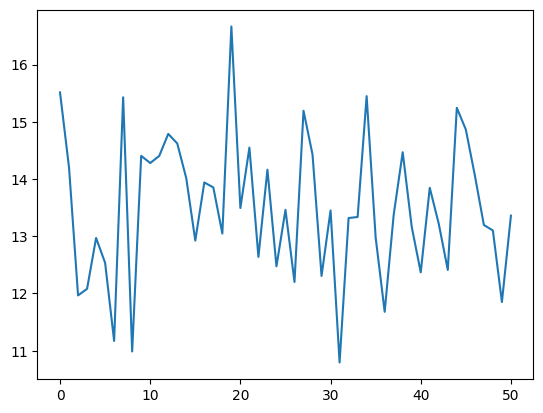

In [ ]:
plt.plot(logs["Full train excess risk"])

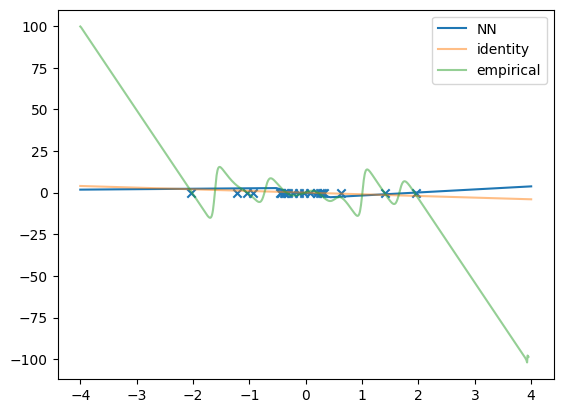

In [ ]:
plot_function(full_dataset, params, exp_params, 4)

In [ ]:
t_list = [.05, .2]
step_size_list = [.5, .1, .05, .01]
n_steps_list = [5000, 25000, 50000, 200000]

In [ ]:
def plot_function(dataset, params, exp_params, xmax=6):
    t = exp_params['t']
    deviation = exp_params.get('deviation', 1)
    sigma = jnp.sqrt(1-jnp.exp(-2 * t))
    mu = jnp.exp(-t)
    x = jnp.linspace(-xmax, xmax, 1000).reshape(-1, 1)
    y = batch_two_layer_nn(params, x)
    z = batch_optimal_score(x, dataset, sigma, mu).reshape(-1, )
    plt.plot(x, y, label = 'NN')
    plt.plot(x, -x/((deviation * mu)**2+sigma**2), label = 'identity', alpha = .5)
    plt.plot(x, z, label = 'empirical', alpha=.5)
    plt.legend()
    plt.scatter(dataset, jnp.zeros_like(dataset), marker = 'x')
    plt.show()

In [ ]:
if rerun:
    res_list_plot_function = []
    for t in t_list:
        print(f'Current t = {t}')
        res_dict = {
            't' : t,
            'dataset': None,
            'step_size': [],
            'params': []
        }
        for step_size, n_steps in zip(step_size_list, n_steps_list):
            print(f'Current learning rate = {step_size}')
            exp_params_1d = {
                't': t,
                'dataset_size': 20,
                'batch_size': 50,
                'step_size': step_size,
                'm': 1000,
                'd': 1,
                'n_steps': n_steps,
                'log_every': 500000,
            }
            logs, params, dataset = training_loop(**exp_params_1d)
            res_dict['dataset'] = dataset
            res_dict['step_size'].append(step_size)
            res_dict['params'].append(params)
        res_list_plot_function.append(res_dict)
else:
    pass

Current t = 0.05
Current learning rate = 0.5


100%|██████████| 5000/5000 [00:03<00:00, 1619.64it/s]


Current learning rate = 0.1


100%|██████████| 25000/25000 [00:15<00:00, 1569.74it/s]


Current learning rate = 0.01


...

100%|██████████| 25000/25000 [00:15<00:00, 1579.63it/s]


Current learning rate = 0.01


100%|██████████| 500000/500000 [05:13<00:00, 1593.71it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

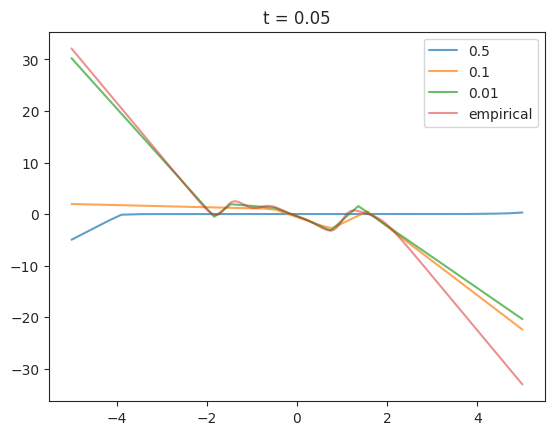

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

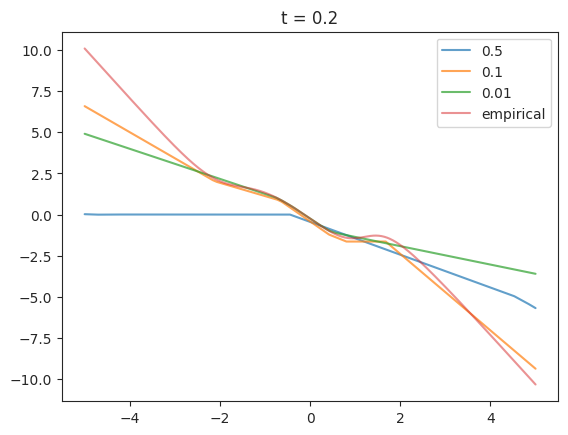

In [ ]:
xmax = 5
for res in res_list_plot_function:
    t = res['t']
    deviation = res.get('deviation', 1)
    sigma = jnp.sqrt(1-jnp.exp(-2 * t))
    mu = jnp.exp(-t)
    x = jnp.linspace(-xmax, xmax, 1000).reshape(-1, 1)
    for lr, params in zip(res['step_size'], res['params']):
        y = batch_two_layer_nn(params, x)
        plt.plot(x, y, label = lr, alpha=.7)
    z = batch_optimal_score(x, res['dataset'], sigma, mu).reshape(-1, )
    # plt.plot(x, -x/((deviation * mu)**2+sigma**2), label = 'identity', alpha = .5)
    plt.plot(x, z, label = 'empirical', alpha=.5)
    plt.legend()
    # plt.scatter(res['dataset'], jnp.zeros_like(res['dataset']), marker = 'x')
    plt.title(f't = {t}')
    plt.savefig('plot_function_t_{}.pdf'.format(t), format='pdf')
    files.download('plot_function_t_{}.pdf'.format(t))
    plt.show()

In [ ]:
res_list_loss_1d = []
for t in t_list:
    print(f'Current t = {t}')
    res_dict = {
        't' : t,
        'step_size': [],
        'loss': []
    }
    key = random.key(0)
    for step_size, n_steps in zip(step_size_list, n_steps_list):
        print(f'Current learning rate = {step_size}')
        n_sims = 10 if step_size==0.01 else 30
        subkeys = random.split(key, n_sims)
        for k in range(n_sims):
            exp_params_1d = {
                't': t,
                'dataset_size': 20,
                'batch_size': 50,
                'step_size': step_size,
                'm': 1000,
                'd': 1,
                'n_steps': n_steps,
                'log_every': 100,
                'num_noise': 5000,
                'key': subkeys[k],
                'log_last': 5
            }
            print(f'Round {k+1}')
            logs, params, dataset = training_loop(**exp_params_1d)
            res_dict['step_size'].append(step_size)
            # print(len(logs['Full train excess risk']))
            excess_risk = sum(logs['Full train excess risk'][-5:])/5
            print(f'{excess_risk=:.5g}')
            res_dict['loss'].append(excess_risk)
    res_list_loss_1d.append(res_dict)
with open('res_list_1d_plot_loss.pkl', 'wb') as f:
    pickle.dump(res_list_loss_1d, f)
files.download('res_list_1d_plot_loss.pkl')

Current t = 0.05
Current learning rate = 0.5
Round 1


100%|██████████| 5000/5000 [00:03<00:00, 1406.84it/s]


excess_risk=2.2678
Round 2


100%|██████████| 5000/5000 [00:03<00:00, 1343.09it/s]


excess_risk=nan
Round 3


...

excess_risk=0.013729
Round 30


100%|██████████| 50000/50000 [00:31<00:00, 1584.29it/s]

excess_risk=-0.026537


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
t_list = [.05, .2]
step_size_list = [.01]
n_steps_list = [200000]
res_list_loss = []
n_sims=10
for t in t_list:
    print(f'Current t = {t}')
    res_dict = {
        't' : t,
        'step_size': [],
        'loss': []
    }
    key = random.key(0)
    for step_size, n_steps in zip(step_size_list, n_steps_list):
        print(f'Current learning rate = {step_size}')
        subkeys = random.split(key, n_sims)
        for k in range(n_sims):
            exp_params_1d = {
                't': t,
                'dataset_size': 20,
                'batch_size': 50,
                'step_size': step_size,
                'm': 1000,
                'd': 1,
                'n_steps': n_steps,
                'log_every': 100,
                'num_noise': 50000,
                'key': subkeys[k],
                'log_last': 5
            }
            print(f'Round {k+1}')
            logs, params, dataset = training_loop(**exp_params_1d)
            res_dict['step_size'].append(step_size)
            # print(len(logs['Full train excess risk']))
            excess_risk = sum(logs['Full train excess risk'][-5:])/5
            print(f'{excess_risk=:.5g}')
            res_dict['loss'].append(excess_risk)
    res_list_loss.append(res_dict)
with open('res_list_1d_plot_loss.pkl', 'wb') as f:
    pickle.dump(res_list_loss, f)
files.download('res_list_1d_plot_loss.pkl')

Current t = 0.05
Current learning rate = 0.01
Round 1


100%|██████████| 200000/200000 [02:00<00:00, 1657.98it/s]


excess_risk=0.20415
Round 2


100%|██████████| 200000/200000 [01:57<00:00, 1696.90it/s]


excess_risk=0.13888
Round 3


...

excess_risk=0.0029197
Round 10


100%|██████████| 200000/200000 [01:56<00:00, 1716.95it/s]

excess_risk=0.0095052


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

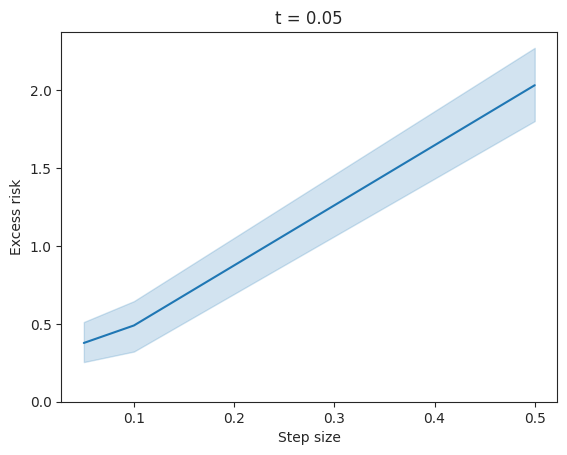

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

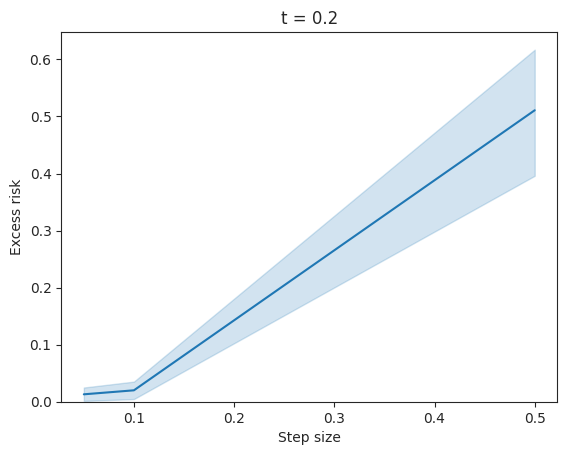

In [ ]:
for res in res_list_loss:
    df_res = pd.DataFrame(res)
    sns.set_style('ticks')
    sns.lineplot(df_res, x = 'step_size', y = 'loss')
    plt.ylabel('Excess risk')
    plt.xlabel('Step size')
    plt.ylim(0,)
    plt.title(f't = {res["t"]}')
plt.savefig('plot_loss.pdf', format='pdf', bbox_inches='tight')
files.download('plot_loss.pdf')
plt.show()

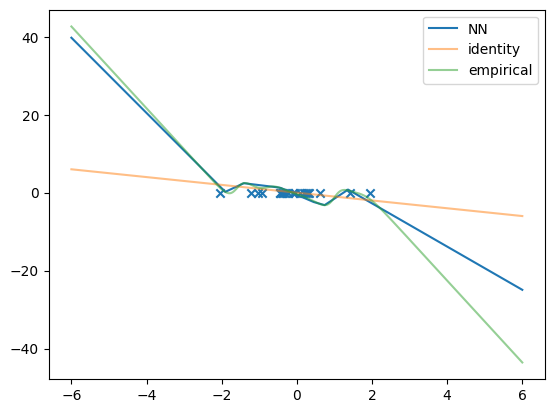

In [ ]:
plot_function(dataset, params, exp_params_, xmax=6)

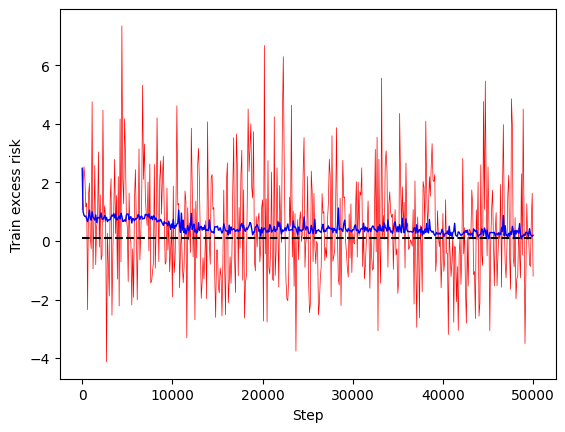

In [ ]:
def plot_loss(df_logs, dataset, exp_params):
    t = exp_params['t']
    sigma = jnp.sqrt(1-jnp.exp(-2*t))
    mu = jnp.exp(-t)
    # optimal_loss = full_optimal_risk(dataset, sigma, mu)
    sns.lineplot(df_logs, x="Step", y="Train excess risk", linewidth=0.5, color="red")
    sns.lineplot(df_logs, x="Step", y="Full train excess risk", linewidth=1.0, color="blue")
    # sns.lineplot(df, x="Step", y="Test risk", linewidth=1.0)
    # plt.hlines([eps**2], xmin=0, xmax=n_steps, linestyles="dashed")
    plt.hlines([0.10], xmin=0, xmax=exp_params['n_steps'], linestyles="dashed", color='black')
    # plt.ylim([0.05, 20])
    plt.show()
plot_loss(df, dataset, exp_params_)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

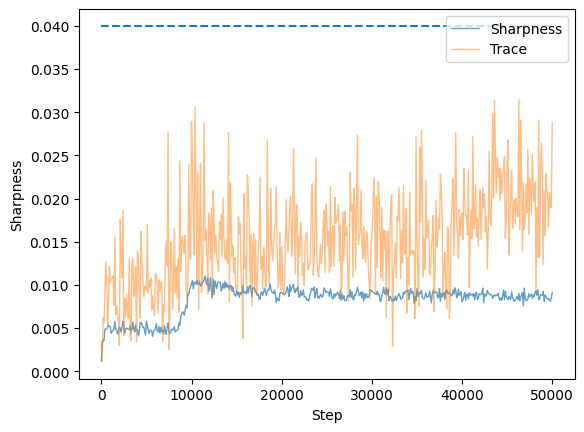

In [ ]:
def plot_sharpness(df, exp_params):
    sns.lineplot(df, x="Step", y="Sharpness", linewidth=1.0, alpha = .7, label = 'Sharpness')
    sns.lineplot(df, x="Step", y="Trace", linewidth=1.0, alpha = .5, label='Trace')
    plt.hlines([2 /exp_params['m']/ exp_params['step_size']], xmin=0, xmax=exp_params['n_steps'], linestyles="dashed")
    plt.legend()
    plt.savefig(f'sharpness_learning_rate_{exp_params["step_size"]}.pdf', format='pdf')
    files.download(f'sharpness_learning_rate_{exp_params["step_size"]}.pdf')
    plt.show()
plot_sharpness(df, exp_params_)

In [ ]:
stepsize_list = [.5, .1, .05, .01]
n_steps_list = [10000, 10000, 20000, 50000]
res_dict = {
    'stepsize': [],
    'round': [],
    'loss': [],
}
num_sims = 30
for stepsize, n_steps in zip(stepsize_list, n_steps_list):
    print(f'Current step size={stepsize}')
    exp_params__= {
      't':0.05,
      'dataset_size': 20,
      'batch_size': 50,
      'step_size': stepsize,
      'm': 1000,
      'd': 10,
      'n_steps': n_steps,
      'log_every': 100,
      'num_noise': 50000,
    }
    key = random.key(0)
    subkeys = random.split(key, num_sims)
    for k in range(num_sims):
        print(f'Round {k+1}')
        logs__, params__, dataset__ = training_loop(
            **exp_params__, key = subkeys[k]
        )
        res_dict['round'].append(k+1)
        res_dict['stepsize'].append(stepsize)
        res_dict['loss'].append(sum(logs__['Full train excess risk'][-5:])/5)

Current step size=0.5
Round 1
optimal_risk=0.014201


100%|██████████| 10000/10000 [00:21<00:00, 460.60it/s]


Round 2
optimal_risk=0.22508


100%|██████████| 10000/10000 [00:21<00:00, 457.51it/s]


Round 3
optimal_risk=0.0050416


...

100%|██████████| 50000/50000 [01:49<00:00, 457.65it/s]


Round 29
optimal_risk=0.021905


100%|██████████| 50000/50000 [01:48<00:00, 461.00it/s]


Round 30
optimal_risk=0.12276


100%|██████████| 50000/50000 [01:48<00:00, 461.85it/s]


In [ ]:
import pickle
from google.colab import files
with open('res.pkl', 'wb') as f:
    pickle.dump(res_dict, f)

files.download('res.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

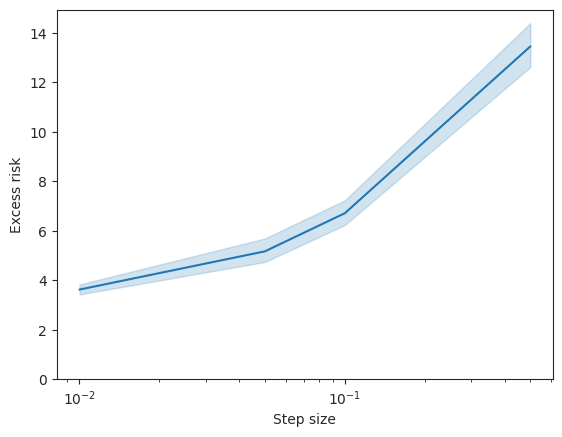

In [ ]:
df_res = pd.DataFrame(res_dict)
sns.set_style('ticks')
sns.lineplot(df_res, x = 'stepsize', y = 'loss')
plt.ylabel('Excess risk')
plt.xlabel('Step size')
plt.ylim(0,)
plt.xscale('log')

In [ ]:
stepsize_list = [.5, .1, .05,]
n_steps_list = [5000, 25000, 50000]
res_dict = {
    'stepsize': [],
    'round': [],
    'loss': [],
}
num_sims = 30
for stepsize, n_steps in zip(stepsize_list, n_steps_list):
    print(f'Current step size={stepsize}')
    exp_params__= {
        't': 0.2,
        'dataset_size': 20,
        'batch_size': 50,
        'step_size': stepsize,
        'm': 1000,
        'd': 10,
        'n_steps': n_steps,
        'log_every': 100,
        'num_noise': 50000,
        'log_last': 5
    }
    key = random.key(0)
    subkeys = random.split(key, num_sims)
    for k in range(num_sims):
        print(f'Round {k+1}')
        logs__, params__, dataset__ = training_loop(
            **exp_params__, key = subkeys[k]
        )
        res_dict['round'].append(k+1)
        res_dict['stepsize'].append(stepsize)
        excess_risk = sum(logs__['Full train excess risk'][-5:])/5
        print(f'{excess_risk=:.5g}')
        res_dict['loss'].append(excess_risk)

with open('res_2.pkl', 'wb') as f:
    pickle.dump(res_dict, f)

files.download('res_2.pkl')

Current step size=0.5
Round 1


100%|██████████| 5000/5000 [00:04<00:00, 1196.08it/s]


excess_risk=3.4991
Round 2


100%|██████████| 5000/5000 [00:04<00:00, 1216.38it/s]


excess_risk=2.8199
Round 3


...

excess_risk=1.9294
Round 30


100%|██████████| 50000/50000 [00:34<00:00, 1438.55it/s]

excess_risk=1.7436


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
stepsize_list = [.01]
n_steps_list = [200000]
res_dict = {
    'stepsize': [],
    'round': [],
    'loss': [],
}
num_sims = 10
for stepsize, n_steps in zip(stepsize_list, n_steps_list):
    print(f'Current step size={stepsize}')
    exp_params__= {
        't': 0.2,
        'dataset_size': 20,
        'batch_size': 50,
        'step_size': stepsize,
        'm': 1000,
        'd': 10,
        'n_steps': n_steps,
        'log_every': 100,
        'num_noise': 50000,
        'log_last': 5
    }
    key = random.key(0)
    subkeys = random.split(key, num_sims)
    for k in range(num_sims):
        print(f'Round {k+1}')
        logs__, params__, dataset__ = training_loop(
            **exp_params__, key = subkeys[k]
        )
        res_dict['round'].append(k+1)
        res_dict['stepsize'].append(stepsize)
        excess_risk = sum(logs__['Full train excess risk'][-5:])/5
        print(f'{excess_risk=:.5g}')
        res_dict['loss'].append(excess_risk)

with open('res_3.pkl', 'wb') as f:
    pickle.dump(res_dict, f)

files.download('res_3.pkl')

Current step size=0.01
Round 1


100%|██████████| 200000/200000 [02:14<00:00, 1490.01it/s]


excess_risk=1.5909
Round 2


100%|██████████| 200000/200000 [02:14<00:00, 1491.80it/s]


excess_risk=1.6292
Round 3


...

excess_risk=1.436
Round 10


100%|██████████| 200000/200000 [02:14<00:00, 1490.04it/s]

excess_risk=1.5056


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>